In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\thasn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
#load data
df = pd.read_csv("twitter.csv")
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [9]:
df.columns

Index(['id', 'label', 'tweet'], dtype='object')

In [10]:
df['tweet'] = df['tweet'].astype(str)

In [11]:
#data preprocessing
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = str(text).lower()   # ⭐ ERROR FIX
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

In [12]:
df['clean_tweet'] = df['tweet'].apply(clean_tweet)
df[['tweet', 'clean_tweet']].head()

,tweet,clean_tweet
0,@user when a father is dysfunctional and is s...,father dysfunct selfish drag kid dysfunct
1,@user @user thanks for #lyft credit i can't us...,thank credit cant use caus dont offer wheelcha...
2,bihday your majesty,bihday majesti
3,#model i love u take with u all the time in ...,love u take u time ur
4,factsguide: society now #motivation,factsguid societi


In [13]:
df['clean_tweet'].isnull().sum()

0

In [14]:
#checks and covert
df['label'].value_counts()

label
0    29720
1     2242
Name: count, dtype: int64

In [15]:
#TF TO IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_tweet'])
y = df['label']

In [16]:
X.shape

(31962, 5000)

In [17]:
#Train and Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
#Model implementation
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
#Prediction & Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9416549350852494
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      5937
           1       0.87      0.21      0.34       456

    accuracy                           0.94      6393
   macro avg       0.91      0.61      0.66      6393
weighted avg       0.94      0.94      0.92      6393



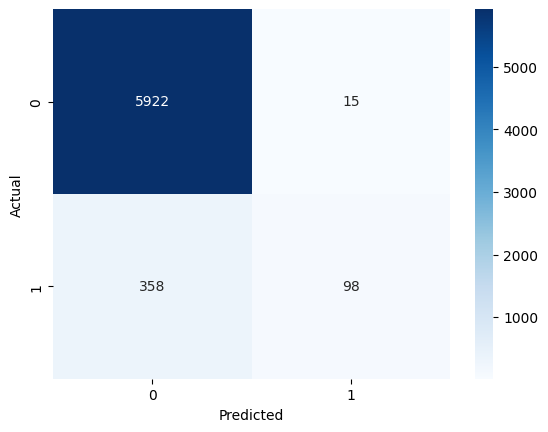

In [20]:
#Visualization(Confusion Matrix)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
#Test with New Tweet
sample_tweet = ["I am very unhappy with this service"]
sample_clean = [clean_tweet(sample_tweet[0])]
sample_vec = vectorizer.transform(sample_clean)

model.predict(sample_vec)

array([0], dtype=int64)

INSIGHTS:
- Text preprocessing (cleaning & stopword removal) improved model accuracy.
- TF-IDF effectively converted textual data into numerical features.
- Logistic Regression performed well for binary sentiment classification.
- The model can be used to analyze customer reviews and social media sentiment.

CONCLUSION:
In this project, sentiment analysis was performed on textual data using NLP techniques.
The dataset was preprocessed and transformed using TF-IDF.
A Logistic Regression model was trained and evaluated successfully.
The model accurately classified sentiments as positive or negative.